In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("Bağlantı başarılı! Veri bilimci laboratuvarına hoş geldin İrem.")

Bağlantı başarılı! Veri bilimci laboratuvarına hoş geldin İrem.


In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [5]:
print(df['TotalCharges'].dtype)

float64


In [6]:
df.drop('customerID', axis=1, inplace=True)

In [7]:
df.shape

(7043, 20)

In [8]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
df.dropna(inplace=True)

In [10]:
print("Eksik veri kontrolü:")
print(df.isnull().sum())

Eksik veri kontrolü:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [11]:
print("\nVerinin yeni boyutu:")
print(df.shape)


Verinin yeni boyutu:
(7032, 20)


In [12]:
print("Müşteri Kayıp Dağılımı (%):")
print(df['Churn'].value_counts(normalize=True) * 100)

Müşteri Kayıp Dağılımı (%):
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


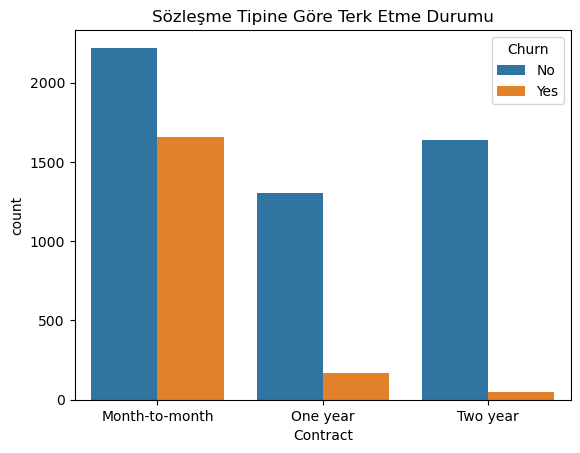

In [13]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Sözleşme Tipine Göre Terk Etme Durumu')
plt.show()

In [14]:
cols_to_encode = ['Contract', 'PaymentMethod', 'InternetService', 'MultipleLines', 
                  'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                  'TechSupport', 'StreamingTV', 'StreamingMovies']
df = pd.get_dummies(df, columns=cols_to_encode)

In [15]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes
0,Female,0,Yes,No,1,No,Yes,29.85,29.85,No,...,False,True,False,False,True,False,False,True,False,False
1,Male,0,No,No,34,Yes,No,56.95,1889.50,No,...,True,True,False,False,True,False,False,True,False,False
2,Male,0,No,No,2,Yes,Yes,53.85,108.15,Yes,...,False,True,False,False,True,False,False,True,False,False
3,Male,0,No,No,45,No,No,42.30,1840.75,No,...,True,False,False,True,True,False,False,True,False,False
4,Female,0,No,No,2,Yes,Yes,70.70,151.65,Yes,...,False,True,False,False,True,False,False,True,False,False


In [16]:
from sklearn.preprocessing import MinMaxScaler



scaler = MinMaxScaler()

cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']



df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [17]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes
0,Female,0,Yes,No,0.000000,No,Yes,0.115423,0.001275,No,...,False,True,False,False,True,False,False,True,False,False
1,Male,0,No,No,0.464789,Yes,No,0.385075,0.215867,No,...,True,True,False,False,True,False,False,True,False,False
2,Male,0,No,No,0.014085,Yes,Yes,0.354229,0.010310,Yes,...,False,True,False,False,True,False,False,True,False,False
3,Male,0,No,No,0.619718,No,No,0.239303,0.210241,No,...,True,False,False,True,True,False,False,True,False,False
4,Female,0,No,No,0.014085,Yes,Yes,0.521891,0.015330,Yes,...,False,True,False,False,True,False,False,True,False,False


In [18]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)

y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_test_split=0.2, random_state=42)



print(f"Eğitim seti boyutu: {X_train.shape}")

print(f"Test seti boyutu: {X_test.shape}")

TypeError: got an unexpected keyword argument 'test_test_split'

In [19]:
from sklearn.model_selection import train_test_split



# Hedef değişkeni (y) ve özellikleri (X) belirliyoruz

X = df.drop('Churn', axis=1)

y = df['Churn']





X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



print(f"Eğitim verisi (X_train) boyutu: {X_train.shape}")

print(f"Test verisi (X_test) boyutu: {X_test.shape}")

Eğitim verisi (X_train) boyutu: (5625, 40)
Test verisi (X_test) boyutu: (1407, 40)


In [20]:
from xgboost import XGBClassifier

model = XGBClassifier()

model.fit(X_train, y_train)



print("Model başarıyla eğitildi! Makine artık tahmin yapmaya hazır.")

ModuleNotFoundError: No module named 'xgboost'

In [21]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   - -------------------------------------- 2.6/101.7 MB 10.4 MB/s eta 0:00:10
   -- ------------------------------------- 5.5/101.7 MB 12.0 MB/s eta 0:00:08
   --- ------------------------------------ 8.7/101.7 MB 12.7 MB/s eta 0:00:08
   ---- ----------------------------------- 11.3/101.7 MB 12.9 MB/s eta 0:00:08
   ----- ---------------------------------- 14.2/101.7 MB 13.1 MB/s eta 0:00:07
   ------ --------------------------------- 17.0/101.7 MB 13.2 MB/s eta 0:00:07
   ------- -------------------------------- 19.9/101.7 MB 13.3 MB/s eta 0:00:07
   --------- ------------------------------ 23.1/101.7 MB 13.3 MB/s eta 0:00:06
   ---------- ----------------------------- 25.7/101.7 MB 13.4 MB/s eta 0:00:06
   ----------- ---------------------------- 28.6/101.7 MB 13.4 MB/s eta 0:00:06
   ------------ --------------------------- 31.5/101.7 MB 13.

In [22]:
from xgboost import XGBClassifier

model = XGBClassifier()
model.fit(X_train, y_train)

print("Model başarıyla eğitildi!")

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1], got ['No' 'Yes']

In [23]:

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})



from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)

y = df['Churn']



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



print("Dönüşüm tamamlandı! Artık y_train içinde sadece 0 ve 1 var.")

Dönüşüm tamamlandı! Artık y_train içinde sadece 0 ve 1 var.


In [24]:
from xgboost import XGBClassifier

model = XGBClassifier()
model.fit(X_train, y_train)

print("Model başarıyla eğitildi!")

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:gender: object, Partner: object, Dependents: object, PhoneService: object, PaperlessBilling: object

In [25]:
df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [26]:
cols_to_convert = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in cols_to_convert:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [27]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
print("Kalan 'object' tipi sütunlar (Boş liste görmeliyiz):")
print(X_train.select_dtypes(include=['object']).columns.tolist())

Kalan 'object' tipi sütunlar (Boş liste görmeliyiz):
[]


In [29]:
from xgboost import XGBClassifier

model = XGBClassifier()
model.fit(X_train, y_train)

print("Tebrikler İrem! Model başarıyla eğitildi.")

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0], got [nan]

In [30]:

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')



df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df.dropna(inplace=True)



if 'customerID' in df.columns:

    df.drop('customerID', axis=1, inplace=True)



df = pd.get_dummies(df, drop_first=True)



X = df.drop('Churn_Yes', axis=1)

y = df['Churn_Yes']



from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



from xgboost import XGBClassifier

model = XGBClassifier()

model.fit(X_train, y_train)



print("VE İŞTE BU! Model başarıyla eğitildi İrem.")

VE İŞTE BU! Model başarıyla eğitildi İrem.


In [31]:
from sklearn.metrics import classification_report
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.83      0.87      0.85      1033
        True       0.59      0.50      0.54       374

    accuracy                           0.77      1407
   macro avg       0.71      0.69      0.69      1407
weighted avg       0.76      0.77      0.77      1407



In [32]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

model_res = XGBClassifier()

model_res.fit(X_train_res, y_train_res)

y_pred_res = model_res.predict(X_test)

print("--- SMOTE Sonrası Performans ---")

print(classification_report(y_test, y_pred_res))

--- SMOTE Sonrası Performans ---
              precision    recall  f1-score   support

       False       0.85      0.83      0.84      1033
        True       0.56      0.59      0.58       374

    accuracy                           0.77      1407
   macro avg       0.71      0.71      0.71      1407
weighted avg       0.77      0.77      0.77      1407



In [33]:
from sklearn.model_selection import RandomizedSearchCV

from xgboost import XGBClassifier

import numpy as np



param_grid = {

    'n_estimators': [100, 200, 300, 400],          

    'max_depth': [3, 4, 5, 6, 8],                  

    'learning_rate': [0.01, 0.05, 0.1, 0.2],      

    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],        

    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0] 

}



xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)



xgb_cv = RandomizedSearchCV(estimator=xgb, param_distributions=param_grid, 

                            n_iter=20, cv=3, verbose=2, random_state=42, n_jobs=-1, scoring='accuracy')



xgb_cv.fit(X_train_res, y_train_res)



print(f"En İyi Parametreler: {xgb_cv.best_params_}")

print(f"En İyi CV Skoru: {xgb_cv.best_score_:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits


C:\Anaconda\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:58:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


En İyi Parametreler: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
En İyi CV Skoru: 0.8282


In [34]:
from sklearn.metrics import classification_report, accuracy_score



best_model = xgb_cv.best_estimator_

y_pred_best = best_model.predict(X_test)



print("--- Final Optimized Model Performance ---")

print(f"Final Accuracy Score: {accuracy_score(y_test, y_pred_best):.4f}")

print("\nClassification Report:")

print(classification_report(y_test, y_pred_best))

--- Final Optimized Model Performance ---
Final Accuracy Score: 0.7605

Classification Report:
              precision    recall  f1-score   support

       False       0.87      0.80      0.83      1033
        True       0.54      0.66      0.60       374

    accuracy                           0.76      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.76      0.77      1407



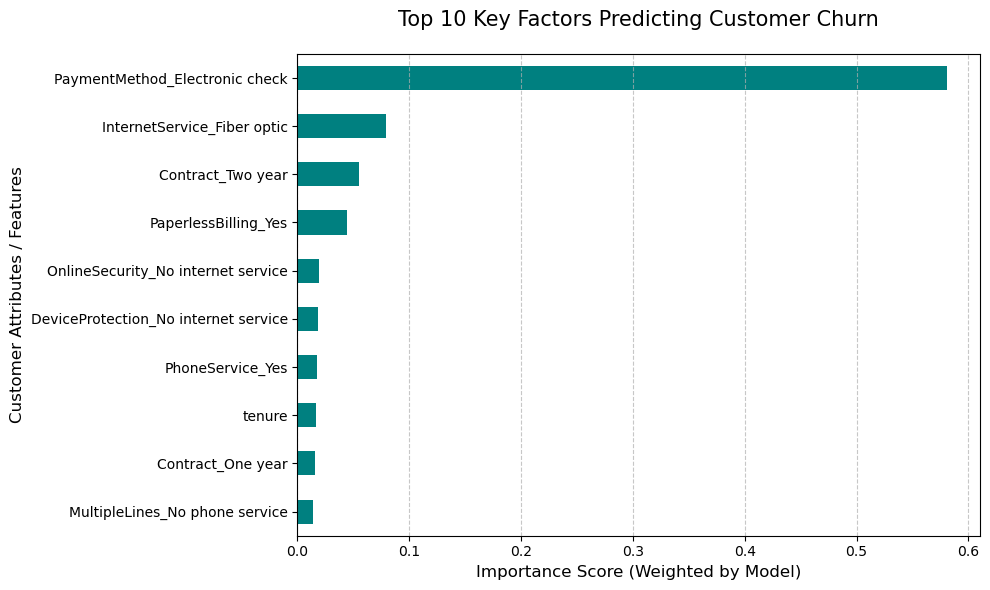

In [35]:
import matplotlib.pyplot as plt



feat_importances = pd.Series(best_model.feature_importances_, index=X.columns)



plt.figure(figsize=(10, 6))

feat_importances.nlargest(10).sort_values(ascending=True).plot(kind='barh', color='teal')



plt.title('Top 10 Key Factors Predicting Customer Churn', fontsize=15, pad=20)

plt.xlabel('Importance Score (Weighted by Model)', fontsize=12)

plt.ylabel('Customer Attributes / Features', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

In [36]:
import joblib



joblib.dump(best_model, 'churn_model_optimized.pkl')

joblib.dump(scaler, 'scaler.pkl')



print("Model 'churn_model_optimized.pkl' adıyla kaydedildi! Artık her yerde kullanabilirsin.")

Model 'churn_model_optimized.pkl' adıyla kaydedildi! Artık her yerde kullanabilirsin.
